In [21]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications import EfficientNetB0 
from tensorflow.keras import layers, models 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint 
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [22]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [23]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [24]:
num_classes = train_data.num_classes

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [25]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    ModelCheckpoint("../models/efficientnet_best.h5", save_best_only=True)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0689 - loss: 3.9419

55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.1075 - loss: 3.6824 - val_accuracy: 0.2107 - val_loss: 3.0188 - learning_rate: 1.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2371 - loss: 3.0128

55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.2630 - loss: 2.8987 - val_accuracy: 0.3867 - val_loss: 2.6808 - learning_rate: 1.0000e-04
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3704 - loss: 2.4868

55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.3836 - loss: 2.4673 - val_accuracy: 0.5120 - val_loss: 2.3849 - learning_rate: 1.0000e-04
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4303 - loss: 2.2934

55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.4585 - loss: 2.2444 - val_accuracy: 0.5520 - val_loss: 2.1547 - learning_rate: 1.0000e-04
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5090 - loss: 2.1134

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8193 - loss: 1.2671 - val_accuracy: 0.7467 - val_loss: 1.5861 - learning_rate: 1.0000e-04
Epoch 25/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8329 - loss: 1.2080

55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8233 - loss: 1.2473 - val_accuracy: 0.7440 - val_loss: 1.5841 - learning_rate: 1.0000e-04
Epoch 26/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8193 - loss: 1.2686

55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8136 - loss: 1.2772 - val_accuracy: 0.7440 - val_loss: 1.5790 - learning_rate: 1.0000e-04
Epoch 27/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8090 - loss: 1.2694

55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8239 - loss: 1.2496 - val_accuracy: 0.7573 - val_loss: 1.5722 - learning_rate: 1.0000e-04
Epoch 28/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8484 - loss: 1.2402

55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8365 - loss: 1.2403 - val_accuracy: 0.7520 - val_loss: 1.5694 - learning_rate: 1.0000e-04
Epoch 29/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8319 - loss: 1.2260 - val_accuracy: 0.7467 - val_loss: 1.5728 - learning_rate: 1.0000e-04
Epoch 30/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8496 - loss: 1.2078 - val_accuracy: 0.7573 - val_loss: 1.5711 - learning_rate: 1.0000e-04


- Train accuracy is 86%

In [26]:
for layer in base_model.layers[-10:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=loss_fn,
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8341 - loss: 1.2083

55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8411 - loss: 1.2034 - val_accuracy: 0.7547 - val_loss: 1.5687 - learning_rate: 1.0000e-06
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8370 - loss: 1.2301 - val_accuracy: 0.7547 - val_loss: 1.5694 - learning_rate: 1.0000e-06
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8485 - loss: 1.1998 - val_accuracy: 0.7547 - val_loss: 1.5692 - learning_rate: 1.0000e-06
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8481 - loss: 1.2165

55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8542 - loss: 1.2007 - val_accuracy: 0.7520 - val_loss: 1.5677 - learning_rate: 1.0000e-06
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8445 - loss: 1.2004 - val_accuracy: 0.7547 - val_loss: 1.5688 - learning_rate: 1.0000e-06
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8519 - loss: 1.2026 - val_accuracy: 0.7547 - val_loss: 1.5690 - learning_rate: 1.0000e-06
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8428 - loss: 1.2004 - val_accuracy: 0.7547 - val_loss: 1.5686 - learning_rate: 1.0000e-06
Epoch 8/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8468 - loss: 1.2123 - val_accuracy: 0.7547 - val_loss: 1.5685 - learning_rate: 3.0000e-07
Epoch 9/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8342 - loss: 1.2309 - val_accuracy: 0.7547 - val_loss: 1.5683 - learning_rate: 3.0000e-07
Epoch 10/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8565 - loss: 1.1984 - 

55/55 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8416 - loss: 1.2067 - val_accuracy: 0.7547 - val_loss: 1.5676 - learning_rate: 9.0000e-08
Epoch 12/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8456 - loss: 1.2081 - val_accuracy: 0.7547 - val_loss: 1.5684 - learning_rate: 9.0000e-08
Epoch 13/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8456 - loss: 1.2104 - val_accuracy: 0.7547 - val_loss: 1.5685 - learning_rate: 9.0000e-08
Epoch 14/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8405 - loss: 1.2096 - val_accuracy: 0.7520 - val_loss: 1.5678 - learning_rate: 2.7000e-08
Epoch 15/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8336 - loss: 1.2279 - val_accuracy: 0.7520 - val_loss: 1.5688 - learning_rate: 2.7000e-08
Epoch 16/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8422 - loss: 1.2041 - val_accuracy: 0.7520 - val_loss: 1.5690 - learning_rate: 2.7000e-08
Epoch 17/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8502 - loss: 1.20

In [27]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7920 - loss: 1.3781
Test Accuracy: 0.7919999957084656


- Test accuracy is 80%

In [28]:
model = models.load_model("../models/efficientnet_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
               precision    recall  f1-score   support

     airplane       0.93      0.93      0.93        15
          bed       0.71      0.67      0.69        15
        bench       0.83      0.67      0.74        15
      bicycle       0.62      0.87      0.72        15
         bird       0.87      0.87      0.87        15
       bottle       0.92      0.80      0.86        15
         bowl       0.50      0.60      0.55        15
          bus       0.85      0.73      0.79        15
         cake       0.87      0.87      0.87        15
          car       0.67      0.80      0.73        15
          cat       0.69      0.73      0.71        15
        chair       0.88      1.00      0.94        15
        couch       0.78      0.47      0.58        15
          cow       0.93      0.93      0.93        15
          cup       0.80      0.53      0.64        15
          dog       0.55      0.73      0.63        15
     elephant       1.00 

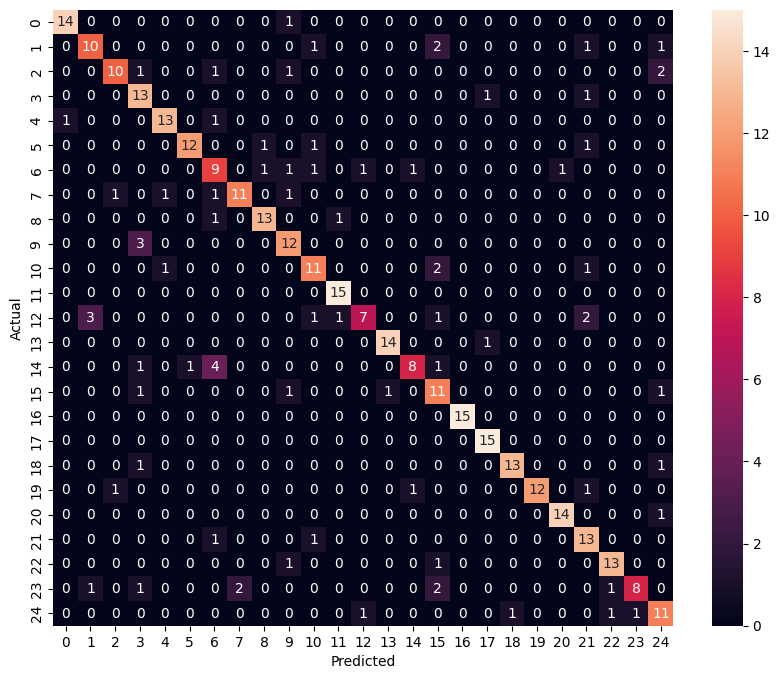

In [29]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()